In [16]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV
import scipy.stats as stats
from sklearn.model_selection import RandomizedSearchCV
from matplotlib import pyplot as plt
from Helpers.data_set_cleaner import import_amazon_reviews_csv_file, amazon_reviews_split
from Helpers.text_processor import TextProcessor

In [17]:
path = r".\..\Data\train.csv"

df = import_amazon_reviews_csv_file(path, 5000)

df

,rating,full_text
0,Neutral,more like funchuck Gave this to my dad for a g...
1,Positive,Inspiring I hope a lot of people hear this cd....
2,Positive,The best soundtrack ever to anything. I'm read...
3,Positive,Chrono Cross OST The music of Yasunori Misuda ...
4,Positive,Too good to be true Probably the greatest soun...
...,...,...
4995,Negative,Waste oF $MONEY$ Waste Of Time & Money... I fo...
4996,Positive,trying to win better This book cuts down the o...
4997,Negative,"don""t waste your money just buy the the lotter..."
4998,Negative,The odds are against you not for you. Winning ...


In [18]:
X_raw, Y = amazon_reviews_split(df)

tp = TextProcessor()
X_processed = tp.preprocess(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, Y, test_size=0.2, random_state=42
)

model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_df=0.95, min_df=3)),
    ('clf', LinearSVC(C = 1.0, class_weight='balanced',random_state=42))
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_df': [0.85, 0.9, 0.95],
    'tfidf__min_df': [2, 3, 5],
    'clf__C': [0.1, 1.0, 10.0]
}

# grid_search = GridSearchCV(
#     model_pipeline,
#     param_grid,
#     cv=5,
#     scoring='f1_macro',
#     n_jobs=-1
# )
#
# grid_search.fit(X_train, y_train)
#
# print(grid_search.best_params_)
# print(grid_search.best_score_)


param_distributions = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_df': stats.uniform(0.7, 0.3), # rozkład jednostajny od 0.7 max 1
    'tfidf__min_df': [1, 2, 3, 5],
    'tfidf__sublinear_tf': [True, False],
    'clf__C': stats.loguniform(1e-2, 1e2)
}

# random_search = RandomizedSearchCV(
#     model_pipeline,
#     param_distributions=param_distributions,
#     n_iter=30,
#     cv=5,
#     scoring='f1_macro',
#     n_jobs=-1,
#     random_state=42
# )
#
# random_search.fit(X_train, y_train)
#
# print(random_search.best_params_)
# print(random_search.best_score_)

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)
print(classification_report(y_test, predictions))

#joblib.dump(model_pipeline, 'amazon_sentiment_model.joblib')

              precision    recall  f1-score   support

    Negative       0.76      0.84      0.80       421
     Neutral       0.52      0.39      0.44       201
    Positive       0.77      0.78      0.78       378

    accuracy                           0.73      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.71      0.73      0.72      1000



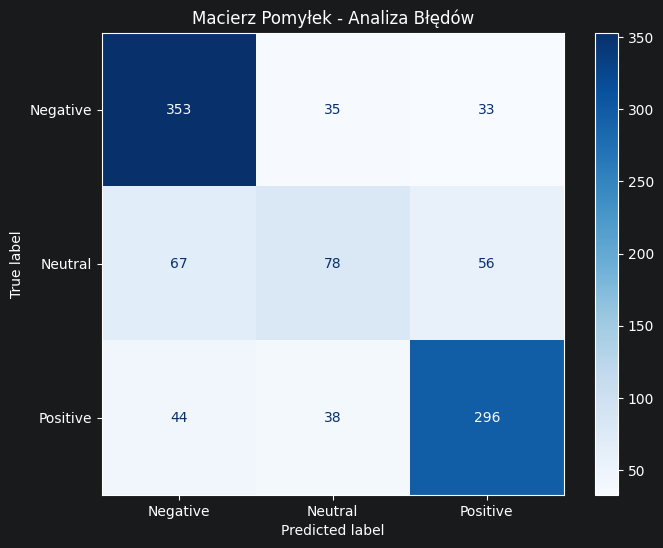

In [19]:
#chyba powinno się jakoś sprawdzać czy negatywnych nie bierze jako pozytywnych, no bo jednak jak jest coś negatywne/pozytywne a klasyfikuje się jako neutralne (lub na odwrót) to nie ma tragedii
etykiety = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, predictions, labels=etykiety)

# 3. Rysujemy wykres
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etykiety)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Macierz Pomyłek - Analiza Błędów")
plt.show()